## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\Siddhesh\Downloads\NLP\shoes_sales_dataset.csv")

In [5]:
df.head()

,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
0,S1,2025-11-24,Nike,Boots,Blue,UK,Online,112.40,4,449.60
1,S2,2025-03-13,Skechers,Boots,Grey,USA,Mall,239.16,4,956.64
2,S3,2025-08-05,Nike,Running,White,UK,Mall,191.04,2,382.08
3,S4,2025-11-05,New Balance,Casual,Green,UAE,Mall,161.70,1,161.70
4,S5,2025-10-07,Adidas,Formal,Grey,France,Online,64.32,14,900.48


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sale_ID        1000 non-null   object 
 1   Date           1000 non-null   object 
 2   Brand          1000 non-null   object 
 3   Shoe_Type      1000 non-null   object 
 4   Color          1000 non-null   object 
 5   Country        1000 non-null   object 
 6   Sales_Channel  1000 non-null   object 
 7   Price_USD      1000 non-null   float64
 8   Units_Sold     1000 non-null   int64  
 9   Revenue_USD    1000 non-null   float64
dtypes: float64(2), int64(1), object(7)
memory usage: 78.3+ KB


In [9]:
df.describe()

,Price_USD,Units_Sold,Revenue_USD
count,1000.000000,1000.000000,1000.00000
mean,137.856420,10.584000,1453.18603
std,64.270059,5.842181,1112.32648
min,31.020000,1.000000,32.38000
25%,81.915000,6.000000,561.05000
50%,139.295000,10.000000,1132.62500
75%,193.752500,16.000000,2163.35000
max,249.940000,20.000000,4938.40000


In [11]:
df.isnull().sum()

Sale_ID          0
Date             0
Brand            0
Shoe_Type        0
Color            0
Country          0
Sales_Channel    0
Price_USD        0
Units_Sold       0
Revenue_USD      0
dtype: int64

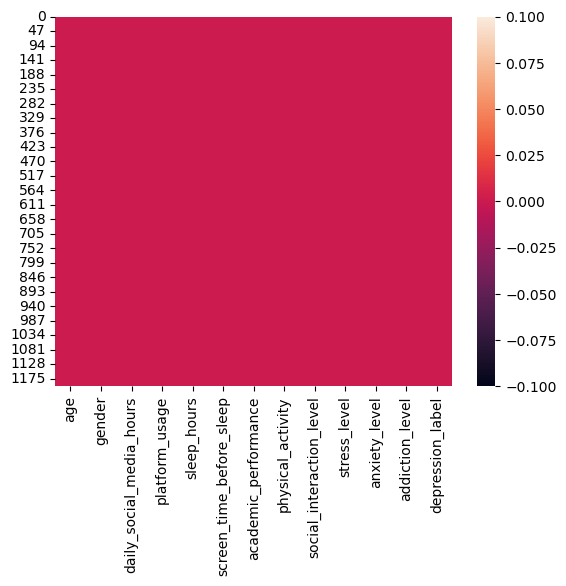

In [8]:
sns.heatmap(df.isnull())
plt.show()

In [9]:
df['screen_exposure'] = df['sleep_hours'] + df['screen_time_before_sleep']

## Performing EDA

### Depression Rate of Gender vs Platform

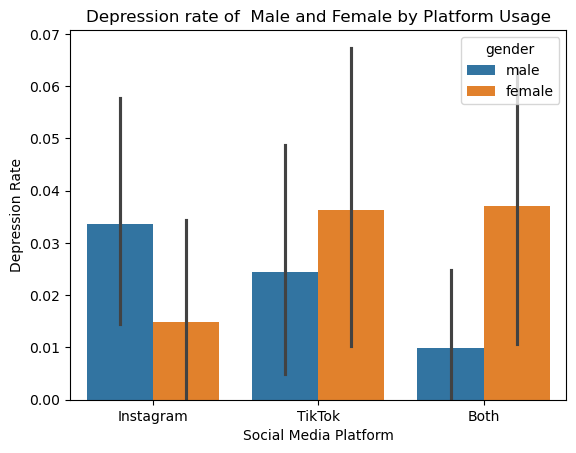

In [12]:
sns.barplot(x='platform_usage', y='depression_label' ,hue = 'gender', data=df)
plt.title('Depression rate of  Male and Female by Platform Usage')
plt.xlabel('Social Media Platform')
plt.ylabel('Depression Rate')
plt.show()

### Social Media Usage Vs Depression Label

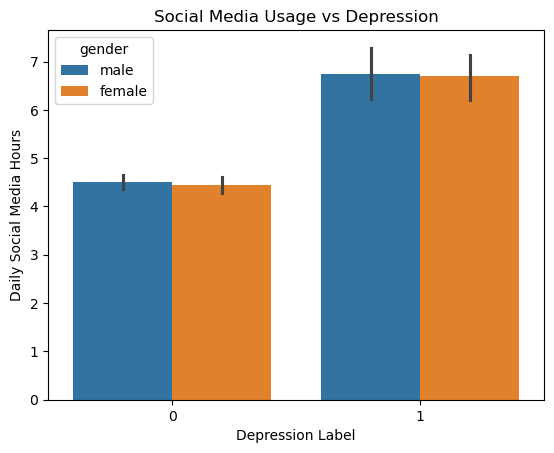

In [14]:
sns.barplot(x='depression_label', y='daily_social_media_hours',hue='gender', data=df)
plt.title('Social Media Usage vs Depression')
plt.xlabel('Depression Label')
plt.ylabel('Daily Social Media Hours')
plt.show()

### Depression Label vs Screen Exposure

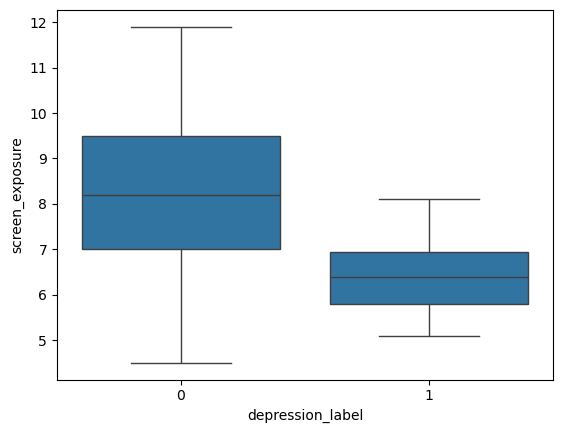

In [16]:
sns.boxplot(x='depression_label',y='screen_exposure',data=df)
plt.show()

In [17]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label',
       'screen_exposure'],
      dtype='object')

### Physical Activity vs Stress Level

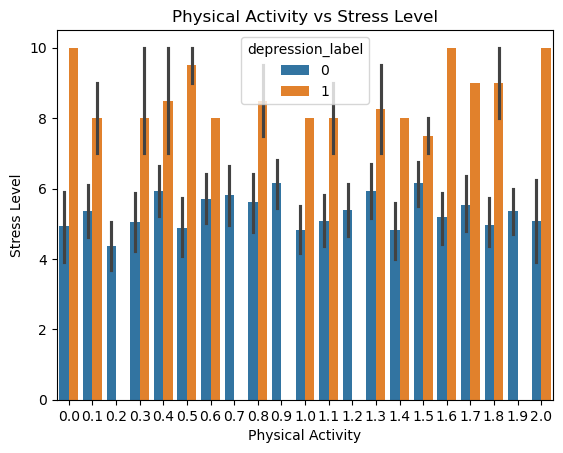

In [19]:
sns.barplot(x='physical_activity',y='stress_level',hue='depression_label',data=df)
plt.xlabel('Physical Activity')
plt.ylabel('Stress Level')
plt.title('Physical Activity vs Stress Level')
plt.show()

### Social Interaction vs Depression

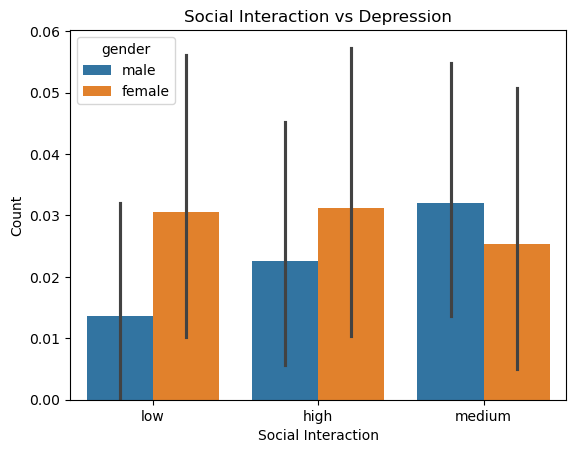

In [21]:
sns.barplot(x='social_interaction_level', y='depression_label',hue='gender', data=df)
plt.title('Social Interaction vs Depression')
plt.xlabel('Social Interaction')
plt.ylabel('Count')
plt.show()

### Corelation Map

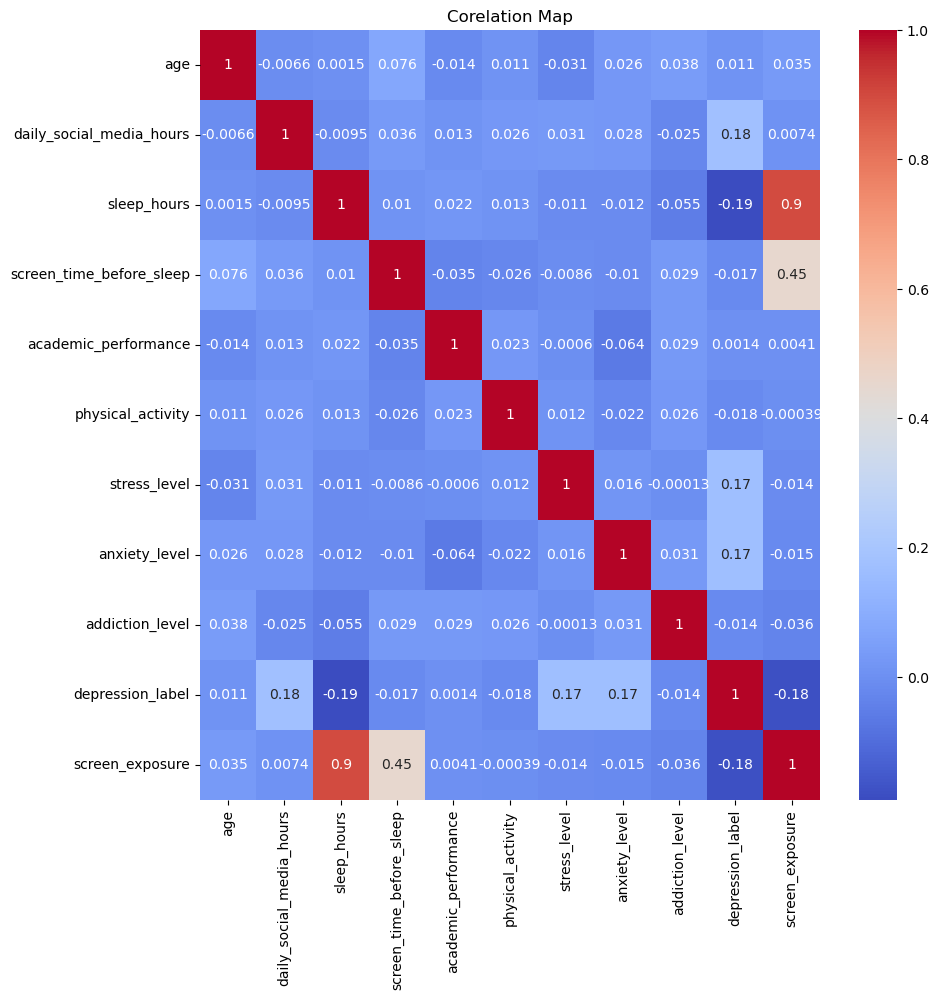

In [23]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True) , annot = True , cmap='coolwarm')
plt.title('Corelation Map')
plt.show()

In [24]:
df['gender'].unique()
df['platform_usage'].unique()
#df['social_interaction_level'].unique

array(['Instagram', 'TikTok', 'Both'], dtype=object)

## Feature Engineering

In [26]:
df['gender'] = df['gender'].map({'female':0 , 'male':1})


In [27]:
df['platform_usage'] = df['platform_usage'].map({'Instagram':0 , 'TikTok':1 , 'Both':2})

In [28]:
df['social_interaction_level'] = df['social_interaction_level'].map({'low':0 , 'high':2 , 'medium':2})

## Model Training Using ML Algorithms

In [30]:
x = df.drop(columns='depression_label',axis=1)
y = df['depression_label']

In [31]:
from sklearn.model_selection import train_test_split


In [32]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

## Using Algorithms For Training
### 1. Logistic Regression
### 2. RandomForestClassifier
### 3. XGBClassifier
### 4. DecisionTreeClassifier

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report , accuracy_score

## Logistic Regression

In [36]:
lr = LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [37]:
y_pred_lr = lr.predict(x_test)
accu_lr = accuracy_score(y_test , y_pred_lr)

In [38]:
print('Logistic Regression Accuracy :' , accu_lr)

Logistic Regression Accuracy : 0.9875


In [39]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       234
           1       0.80      0.67      0.73         6

    accuracy                           0.99       240
   macro avg       0.90      0.83      0.86       240
weighted avg       0.99      0.99      0.99       240



## RandomForestClassifier

In [41]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [42]:
y_pred_rfc = rfc.predict(x_test)
accu_rfc = accuracy_score(y_test , y_pred_rfc)

In [43]:
print('RandomForestClassifier Accuracy :', accu_rfc)

RandomForestClassifier Accuracy : 0.9833333333333333


In [44]:
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       234
           1       1.00      0.33      0.50         6

    accuracy                           0.98       240
   macro avg       0.99      0.67      0.75       240
weighted avg       0.98      0.98      0.98       240



## XGBClassifier

In [46]:
xg = XGBClassifier()
xg.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [47]:
y_pred_xg = xg.predict(x_test)
accu_xg = accuracy_score(y_test , y_pred_xg)

In [48]:
print('XGBClassifier Accuracy :',accu_xg)

XGBClassifier Accuracy : 0.9958333333333333


In [49]:
print(classification_report(y_test , y_pred_xg))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      0.83      0.91         6

    accuracy                           1.00       240
   macro avg       1.00      0.92      0.95       240
weighted avg       1.00      1.00      1.00       240



## DecisionTreeClassifier

In [51]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [52]:
y_pred_dt = dt.predict(x_test)
accu_dt = accuracy_score(y_test , y_pred_dt)

In [53]:
print("Decision Tree Classifier Accuracy :", accu_dt)

Decision Tree Classifier Accuracy : 0.9916666666666667


In [54]:
print(classification_report(y_test , y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       0.83      0.83      0.83         6

    accuracy                           0.99       240
   macro avg       0.91      0.91      0.91       240
weighted avg       0.99      0.99      0.99       240



## Summary

### Logistic Regression Accuracy : 0.9916
### RandomForestClassifier Accuracy : 0.9791
### XGBClassifier Accuracy : 0.9958
### Decision Tree Classifier Accuracy : 0.9916

## XGBoost classifier achieved an accuracy of 99.58%, indicating excellent predictive performance.

In [100]:
import pickle

# Save trained model
pickle.dump(xg, open("mental_health_model.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully


In [102]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] TARGET [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [104]:
import os

os.chdir(r"C:\Users\Siddhesh\OneDrive\Documents\MentalHealthApp")
print(os.getcwd())

C:\Users\Siddhesh\OneDrive\Documents\MentalHealthApp


In [106]:
os.listdir()

['app.py', 'mental_health_model.pkl', 'requirements.txt', '~$app.py']

In [ ]:
!python -m streamlit run app.py